In [1]:
import os as os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from scipy.signal import get_window
from gwpy.timeseries import TimeSeriesDict
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

# Import user defined files
from bethLISA.lisa_glitch_simulation.plotting import plot_all_four
from scripts.lpsd import lpsd
# from scripts.psdAndPlot import psd_and_plot_hor

import scripts.runCommands
importlib.reload(scripts.runCommands)
from scripts.runCommands import run_make_and_inject

# Note: if you change a file, but the change is not reflected when you run the notebook,
# Then, just restart the kernel 
# alternatively, use the importlib.reload function

from scripts.wosa import wosa
from scripts.lpsd import lpsd, lpsd_wosa
from scripts.logpsd import logpsd
from scripts.plot import plot
from scripts.readTdi import readTdi, getTdiPath
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
plt.rcParams['text.usetex'] = False


/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

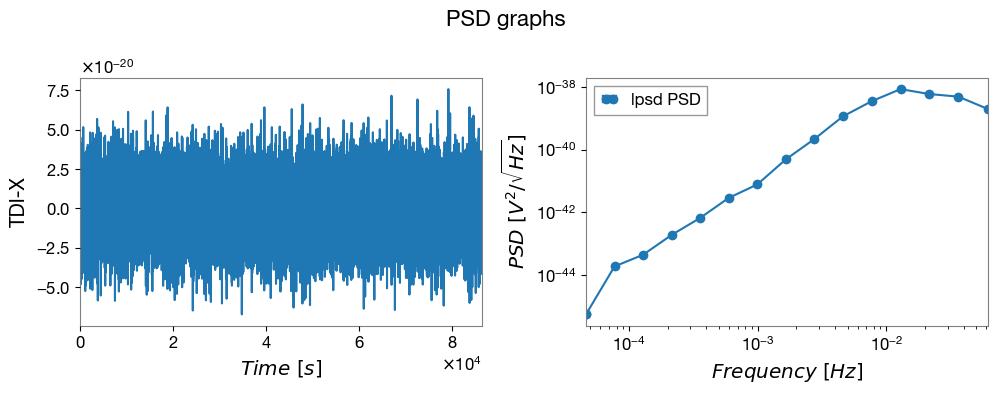

In [2]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig_logpsd, psd_orig_logpsd, _ = logpsd(
    x=data_orig, 
    fs=fs, 
    overlap=0, 
    L1=17280
)

f_median, psd_median, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# # Plot the original psd for no reason 
# plot(
#     data=data_orig,
#     t=t, 
#     f=f_orig, 
#     psd= [psd_orig, psd_median],
#     labels= ["mean PSD", "median PSD"],
#     title="TDI-X", 
#     bigtitle="PSD graphs",
#     f_lims = [(fs / nperseg), (fs / 2.0)]
# )

# plot(
#     data=data_orig,
#     t=t, 
#     f=f_orig, 
#     psd= [psd_orig, psd_median],
#     labels= ["mean PSD", "median PSD"],
#     title="TDI-X", 
#     bigtitle="PSD graphs",
#     f_lims = [(fs / nperseg), f_orig[-1]]
# )

plot(
    data=data_orig,
    t=t, 
    f=f_orig_logpsd, 
    psd= [psd_orig_logpsd],
    labels= ["lpsd PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_logpsd[0], f_orig_logpsd[-1]],
    logpsd=True
)

In [3]:
f_orig_lpsd, psd_orig_lpsd, _, _ = lpsd(
    x=data_orig,
    fs=fs,
    fmin=fs/len(data_orig), 
    fmax=fs/2,
    Kdes = 100,
    Kmin = 1
)

f_orig_lpsd_2, psd_orig_lpsd_2, _, _ = lpsd_wosa(
    x=data_orig, 
    fs=fs,
    fmin=fs/len(data_orig), 
    fmax=fs/2,
    W_des=100, 
    W_min=1, 
    xi=0.5,
    Jdes=1000,
    wosa_kwargs=dict(method="mean")   # whatever options your wosa supports
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

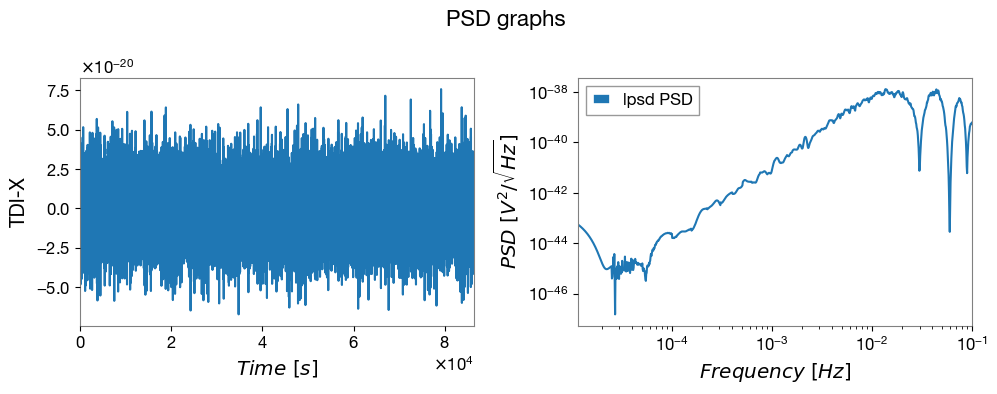

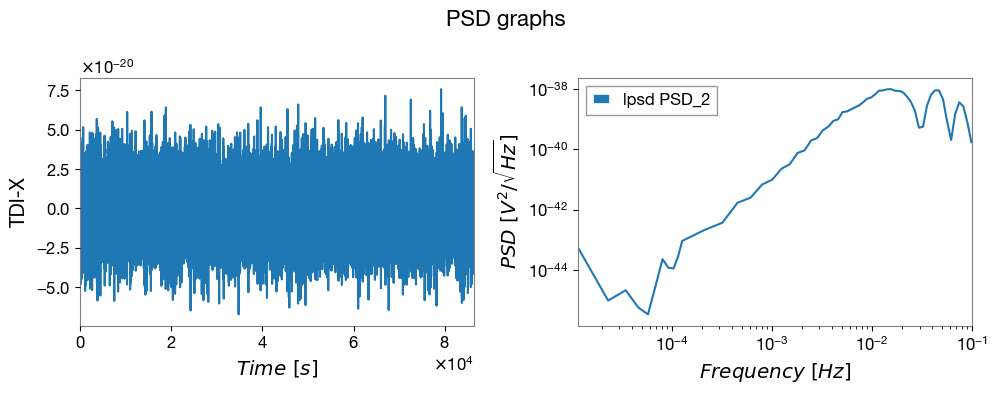

In [4]:
plot(
    data=data_orig,
    t=t, 
    f=f_orig_lpsd, 
    psd= [psd_orig_lpsd],
    labels= ["lpsd PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_lpsd[0], (fs / 2.0)]
)

plot(
    data=data_orig,
    t=t, 
    f=f_orig_lpsd_2, 
    psd= [psd_orig_lpsd_2],
    labels= ["lpsd PSD_2"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_lpsd_2[0], (fs / 2.0)]
)

In [5]:
print(f_orig)
print(f_orig_logpsd)
print(f_orig_lpsd)

[0.     0.0001 0.0002 ... 0.0998 0.0999 0.1   ]
[4.62962963e-05 4.62962963e-05 7.71604938e-05 1.28617363e-04
 2.14362272e-04 3.57302367e-04 5.95681310e-04 9.92555831e-04
 1.65631470e-03 2.75862069e-03 4.59770115e-03 7.69230769e-03
 1.29032258e-02 2.16216216e-02 3.63636364e-02 6.15384615e-02]
[1.15740741e-05 1.16795662e-05 1.17860198e-05 ... 9.82017193e-02
 9.90967806e-02 1.00000000e-01]


In [8]:
dx = 5
no_glitch_integral = np.trapz(np.abs(data_orig[6000-20: 6000+20]), dx=dx)
print(no_glitch_integral)

1.9935007723480114e-18


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

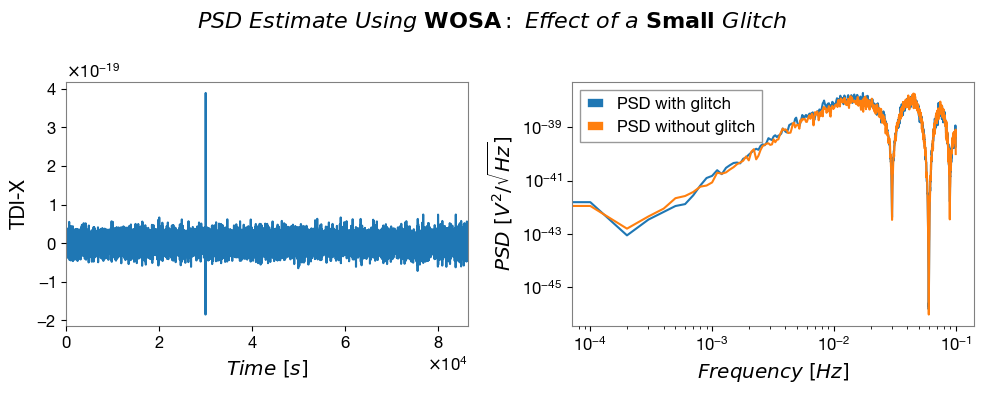

In [7]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
)

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

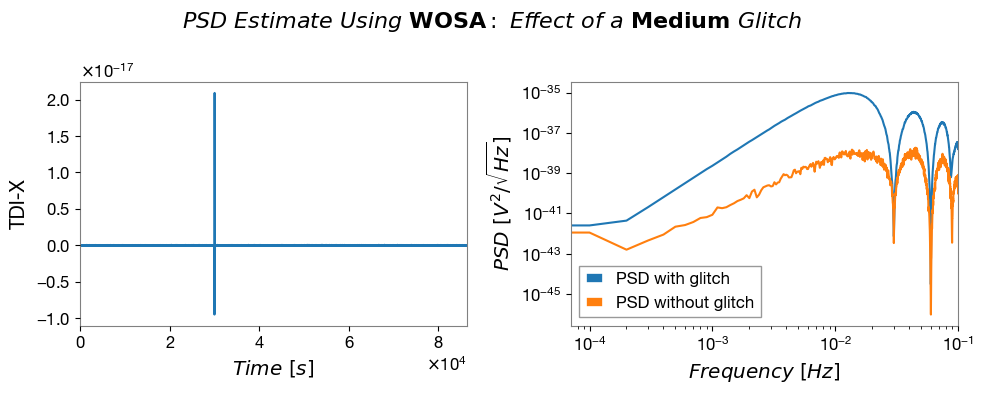

In [8]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    f_lims = [f_mean[0], f_mean[-1]],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

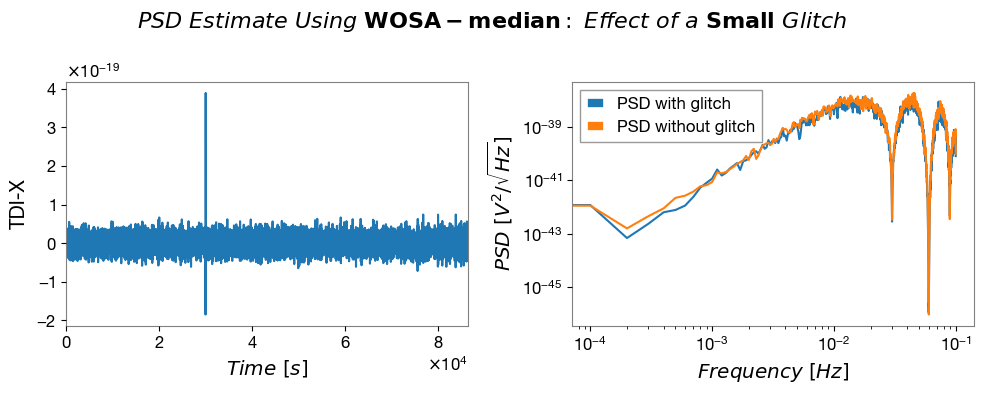

In [9]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

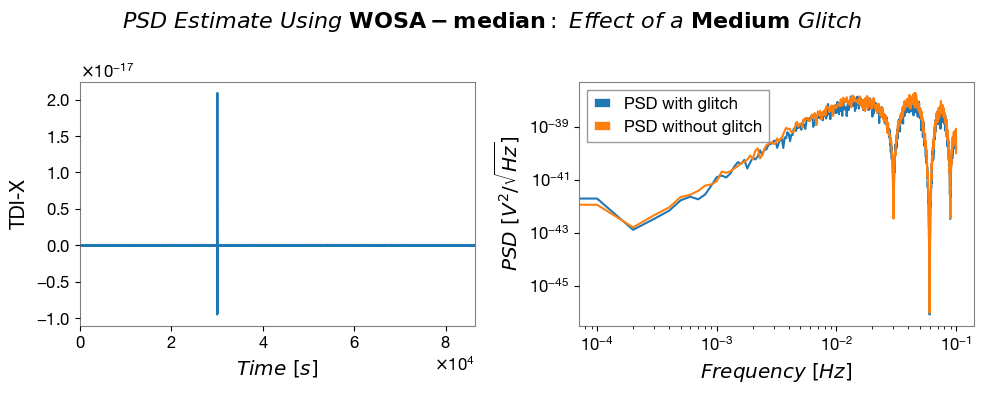

In [10]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$",
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

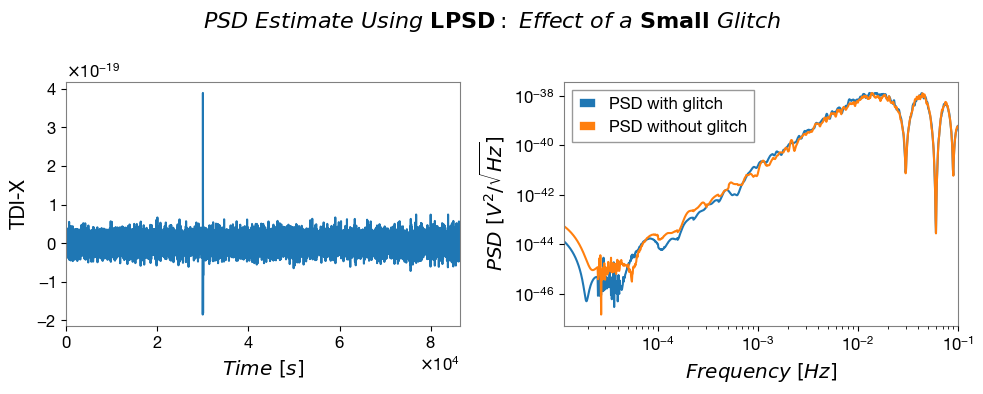

In [12]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_lpsd, 
    f_lims = [f_lpsd[0], fs/2.0],
    psd= [psd_lpsd, psd_orig_lpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

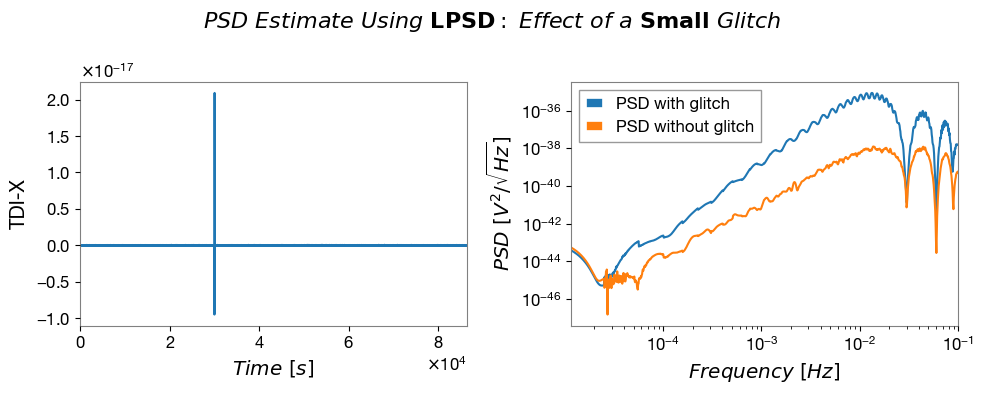

In [14]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_lpsd, 
    f_lims = [f_lpsd[0], fs/2.0],
    psd= [psd_lpsd, psd_orig_lpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$"
)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

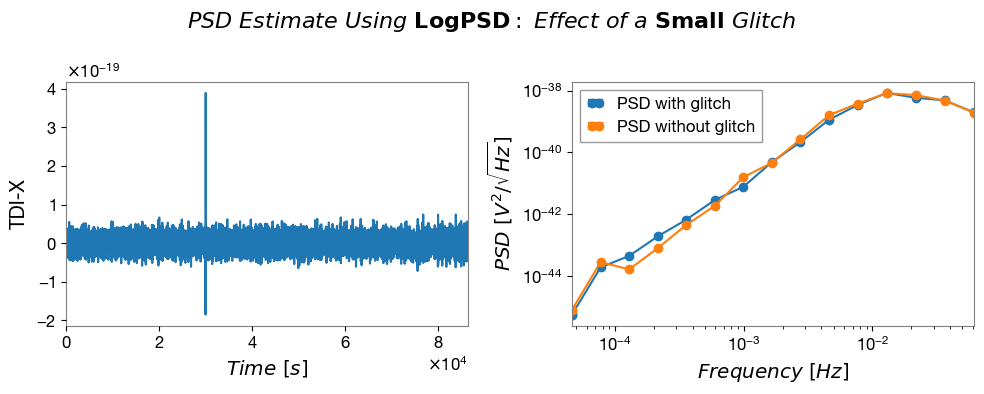

In [15]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17280
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_orig_logpsd, psd_logpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    f_lims = [f_logpsd[0], f_logpsd[-1]],
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LogPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
    logpsd = True
)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

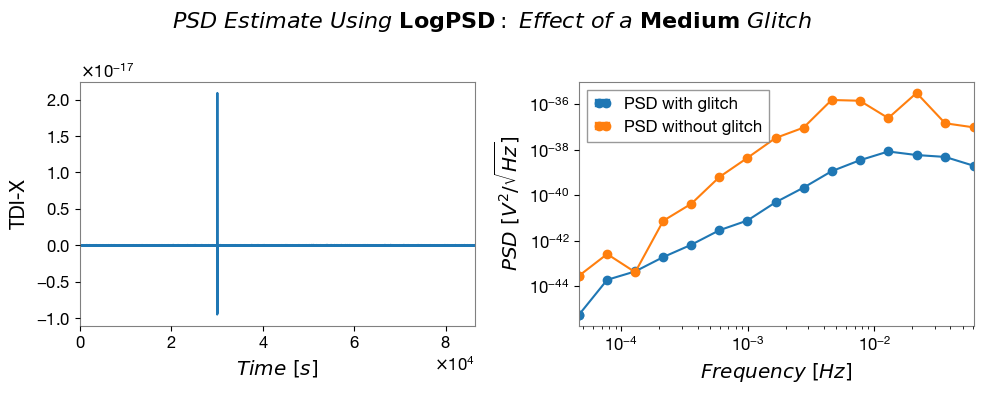

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17280
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_orig_logpsd, psd_logpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    f_lims = [f_logpsd[0], f_logpsd[-1]],
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LogPSD}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$",
    logpsd = True
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

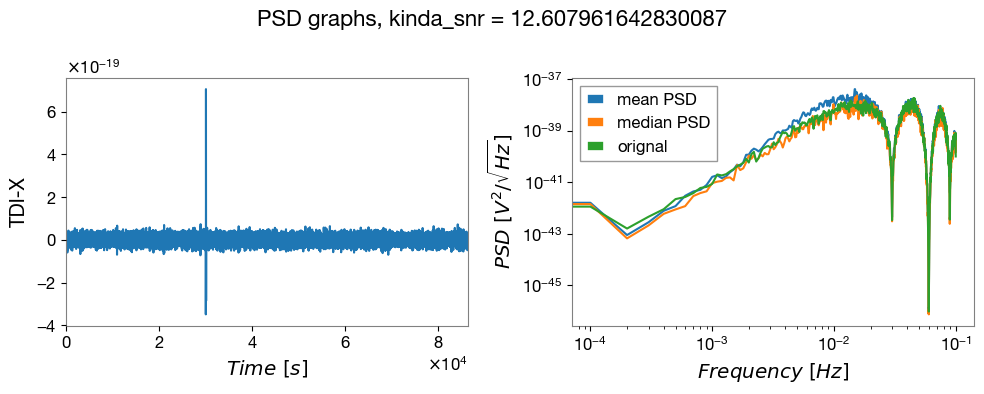

In [17]:
tdi_path = getTdiPath('glitch_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

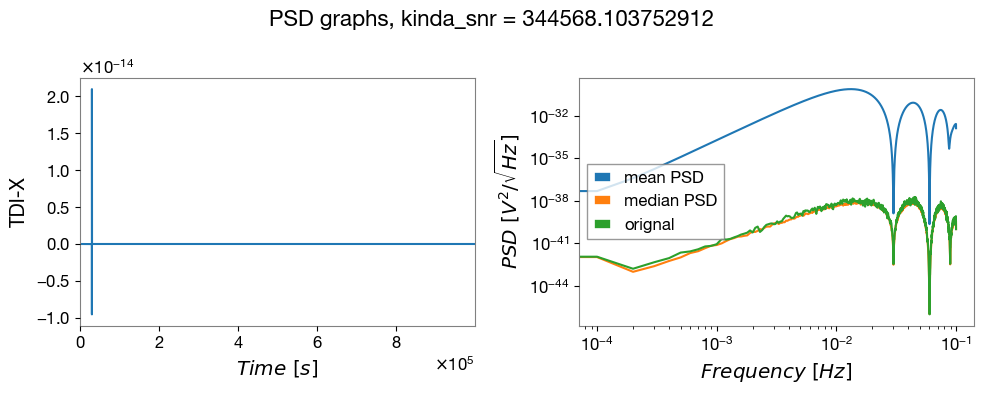

In [19]:
tdi_path = getTdiPath('glitch_8.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

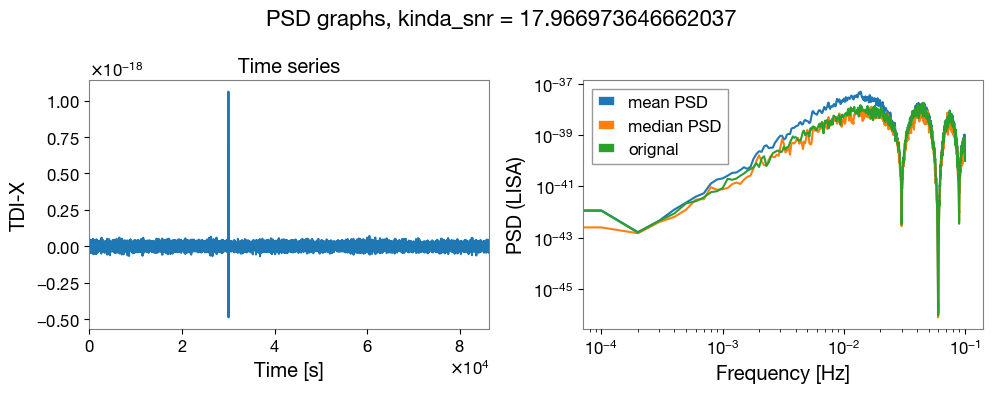

In [ ]:
tdi_path = getTdiPath('glitch_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

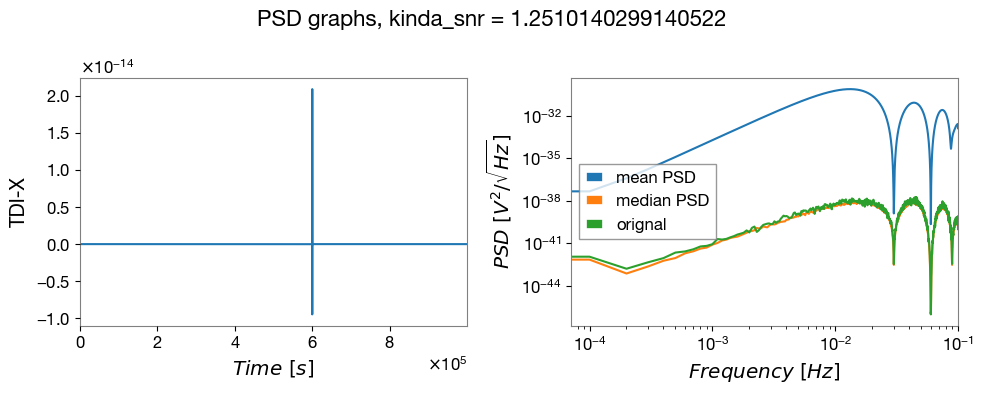

In [21]:
tdi_path = getTdiPath('glitch_9.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

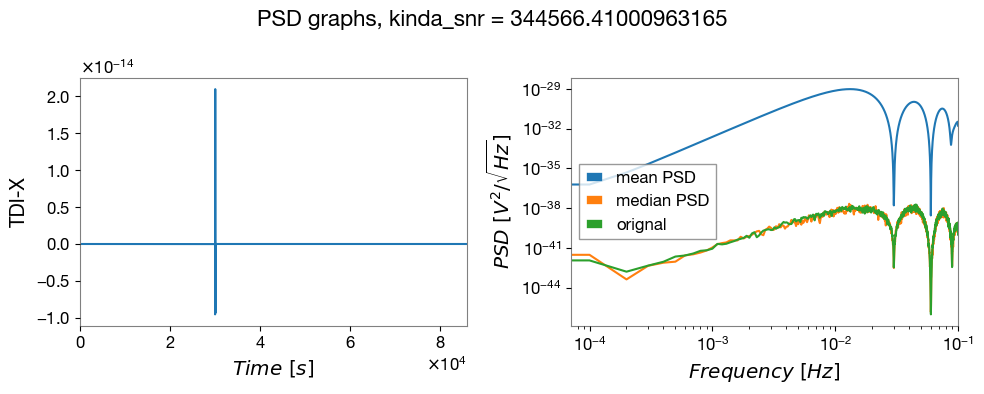

In [22]:
tdi_path = getTdiPath('glitch_9_one_day.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

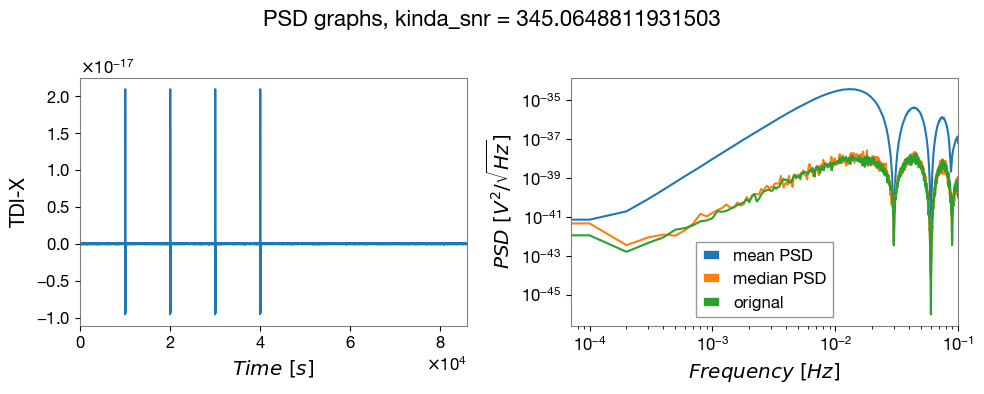

In [24]:
tdi_path = getTdiPath('glitch_7_multiple.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

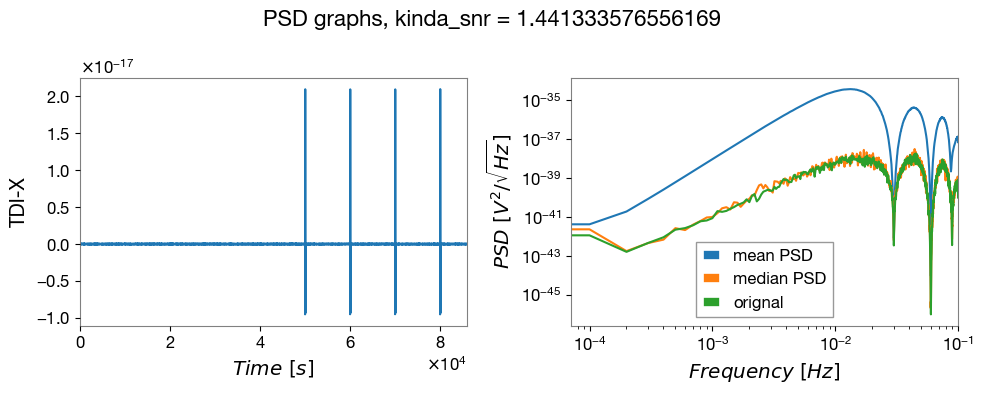

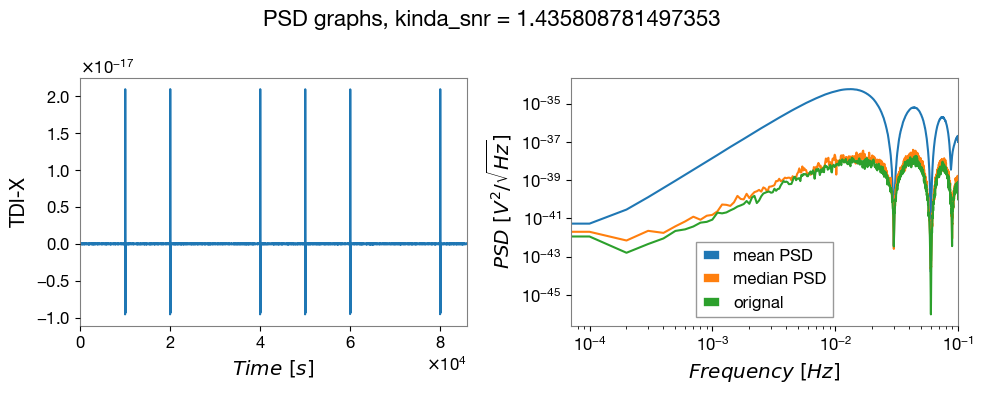

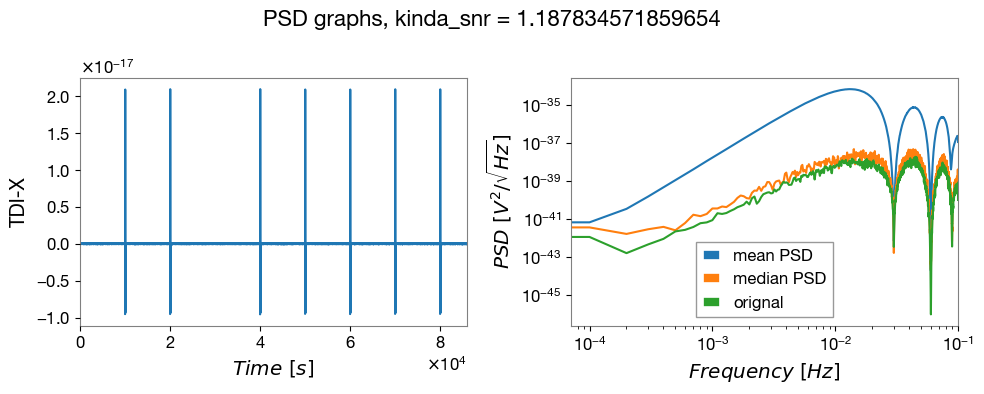

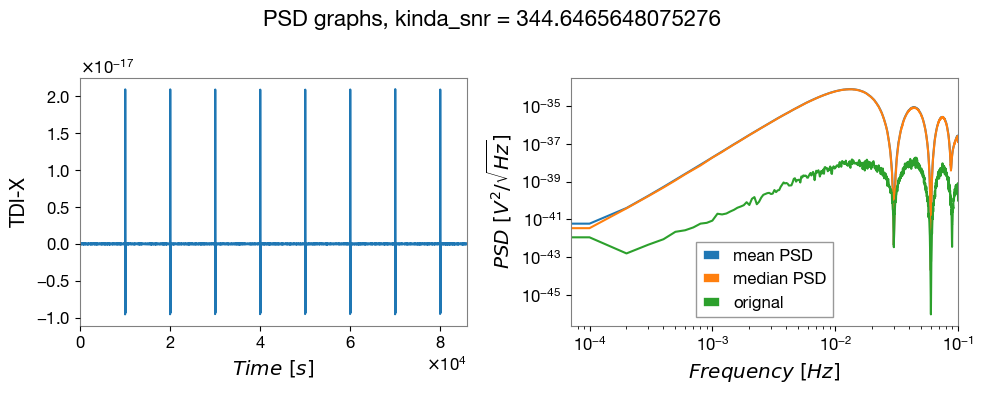

In [30]:

##################################

tdi_path = getTdiPath('glitch_7_multiple_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


#####################################

tdi_path = getTdiPath('glitch_7_multiple_4.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)



#####################################
tdi_path = getTdiPath('glitch_7_multiple_5.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


############################
tdi_path = getTdiPath('glitch_7_multiple_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


In [5]:
data.size

17200

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17000, 17000, 10200, 6120, 3671, 2203, 1321, 793, 475, 285, 171, 102, 61, 37, 22, 13]
fk_list: [4.705882352941177e-05, 4.705882352941177e-05, 7.843137254901961e-05, 0.00013071895424836603, 0.00021792427131571779, 0.00036314117113027687, 0.0006056018168054504, 0.001008827238335435, 0.0016842105263157896, 0.002807017543859649, 0.004678362573099415, 0.00784313725490196, 0.013114754098360656, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]
['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17000, 17000, 10200, 6120, 3671,

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

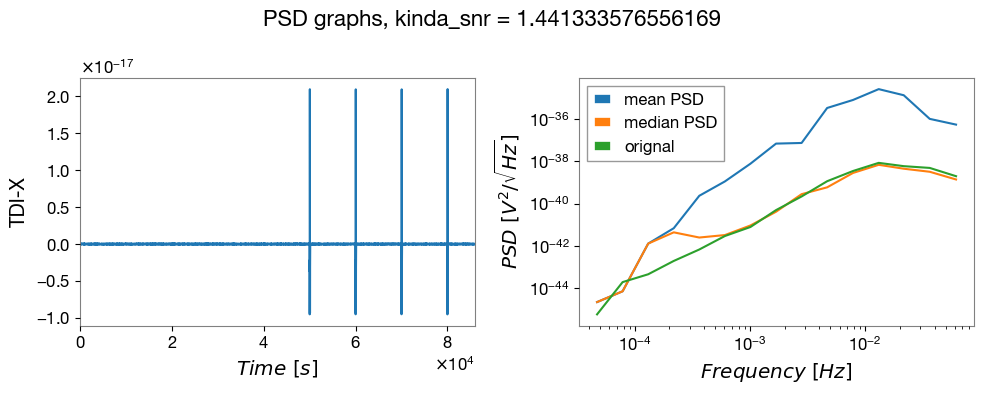

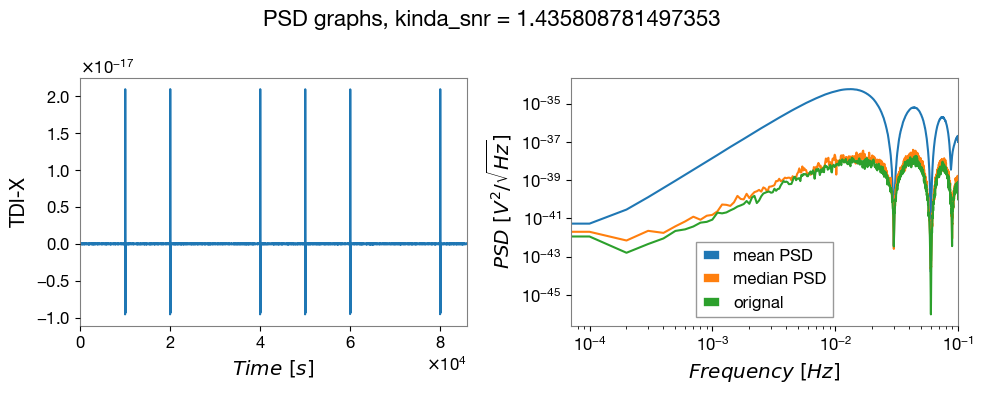

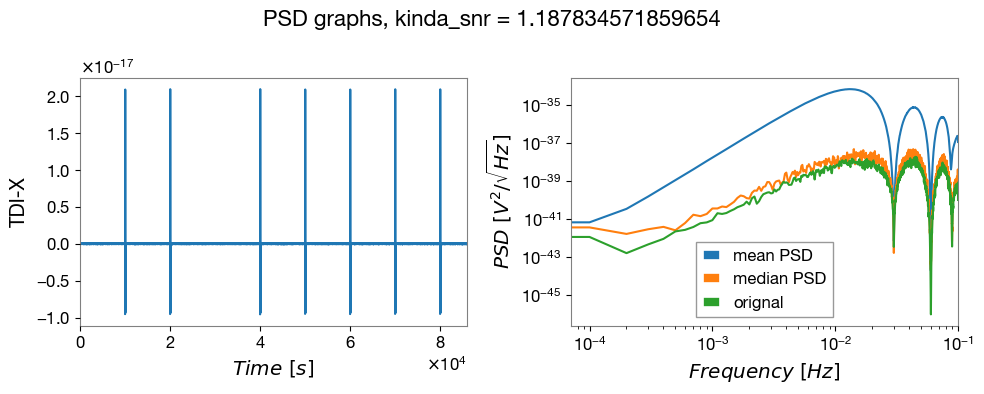

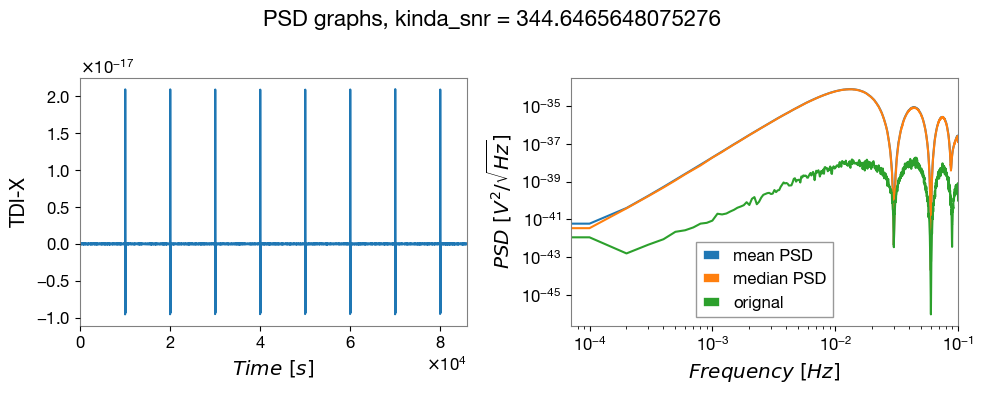

In [12]:

##################################

tdi_path = getTdiPath('glitch_7_multiple_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17000
) 
f_logpsd_median, psd_logpsd_median, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17000, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_logpsd, psd_logpsd_median, psd_orig_logpsd],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)


#####################################

tdi_path = getTdiPath('glitch_7_multiple_4.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)



#####################################
tdi_path = getTdiPath('glitch_7_multiple_5.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


############################
tdi_path = getTdiPath('glitch_7_multiple_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

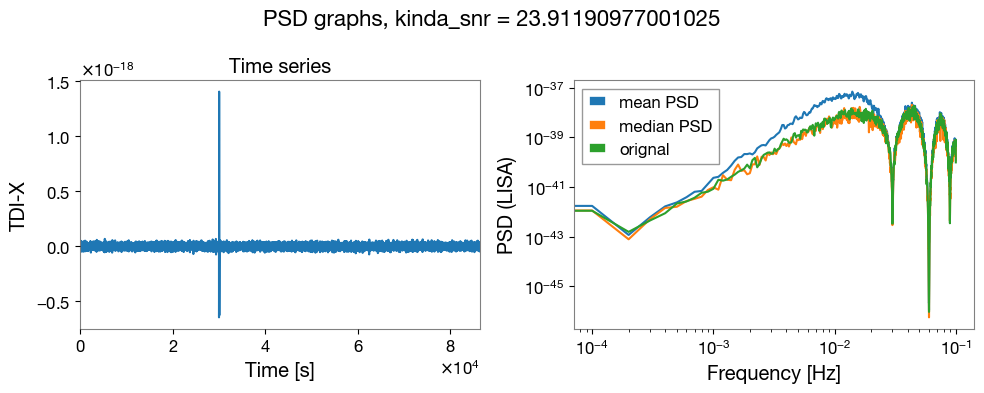

In [ ]:
tdi_path = getTdiPath('glitch_4.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

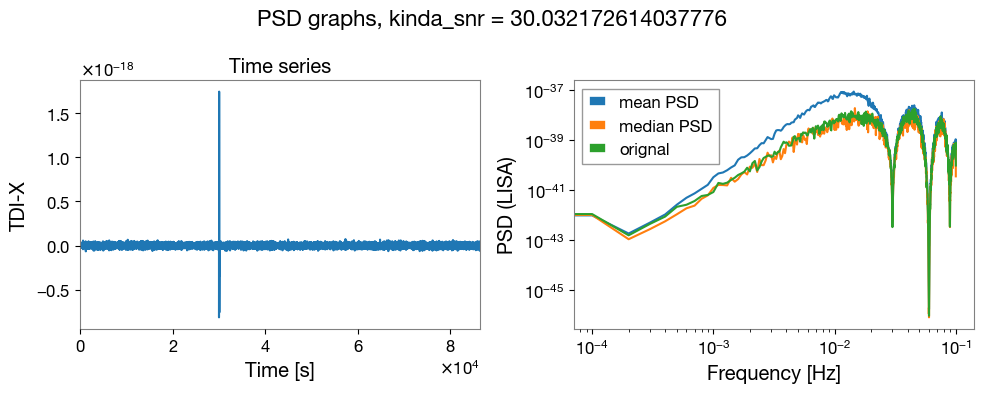

In [ ]:
tdi_path = getTdiPath('glitch_5.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

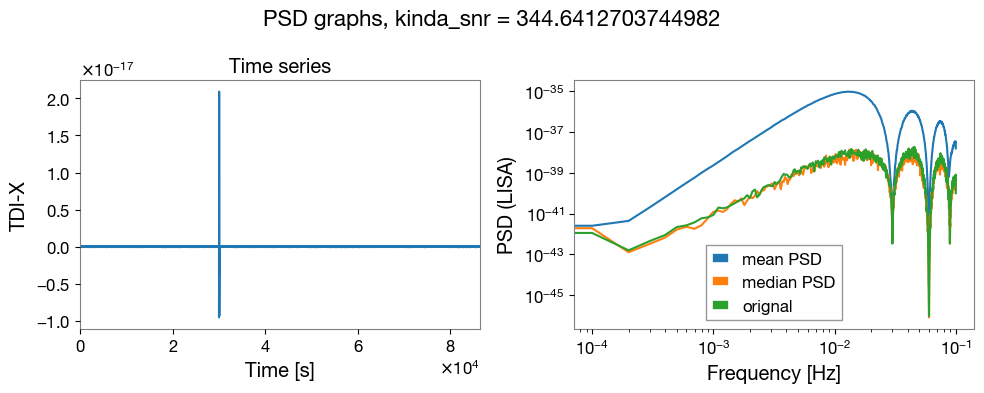

In [ ]:
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

In [ ]:
tdi_path = getTdiPath('glitch_6.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=2*nseg
)

NameError: name 'dx' is not defined

In [ ]:
# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    psd_orig, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)
f_noise, noise_psds, nseg = n_noise_psds(
    time_noises, 
    fs, 
    nperseg, 
    noverlap=50, 
    window='hann'
)

psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)


In [ ]:
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 5000
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

NameError: name 'dx' is not defined

In [ ]:
print(nseg[0])

16
